# Running a TPS simulation

This notebook gives a run-through of how to set up multiple state transition interface sampling. Here, we will use the toy model engine that is built into OPS. However, you'll see that the process of setting up a path sampling simulation is the same: set up engine, then CVs, then states (and interfaces for TIS), then the sampling network, then the move scheme. After that, you're ready to run your simulation!

This notebook does not include any "YOUR TURN" steps; it can just be run directly.

Tasks covered in this notebook:
* Loading OPS objects from storage
* Ways of assigning initial trajectories to initial samples
* Setting up a path sampling simulation with various move schemes
* Visualizing trajectories while the path sampling is running

In [1]:
from __future__ import print_function
%matplotlib inline
import sys
import openpathsampling as paths
import numpy as np


# toy_plot_helpers.py has conveniences for plotting the 2D contour plots, etc.
%run ./toy_plot_helpers.py
%run muller_brown.py

## Setting up the engine

First we set up our system: for the toy dynamics, this involves defining a potential energy surface (PES), setting up an integrator, and giving the simulation an initial configuration. In real MD systems, the PES is handled by the combination of a topology file and a force field definition, and the initial configuration would come from a file instead of being described by hand.

First we need to describe the system we'll be simulating. With biomolecular systems, this is often done with an initial PDB structure and a choice of force field. For the toy model, we need to give a snapshot as a template, as well as a potential energy surface. The template snapshot also includes a pointer to the topology information (which is relatively simple for the toy systems.)

In [2]:
# convenience for the toy dynamics
import openpathsampling.engines.toy as toys

# Toy_PES supports adding/subtracting various PESs. 
# The OuterWalls PES type gives an x^6+y^6 boundary to the system.
pes = MullerBrownPES(beta=1.0)

topology=toys.Topology(
    n_spatial=2,
    masses=[1.0, 1.0],
    pes=pes
)

integ = toys.LangevinBAOABIntegrator(dt=1e-3, temperature=3.0, gamma=0.5)

options={
    'integ' : integ,
    'n_frames_max' : int(5e4),
    'n_steps_per_frame' : 1
}

engine = toys.Engine(
    options=options,
    topology=topology
)

In [3]:
class Point:
    def __init__(self, x: float, y: float):
        self.positions = [x, y]

    def __add__(self, other: np.ndarray):
        return Point(self.positions[0] + other[0], self.positions[1] + other[1])
    
    def __sub__(self, other: np.ndarray):
        return Point(self.positions[0] - other[0], self.positions[1] - other[1])

def descent_path(x0: Point, step_size: float = 1e-4, n_steps:int = 500) -> np.ndarray:
    all_pos: list[list[float]] = [x0.positions]
    x = x0
    for _ in range(n_steps):
        x = x - step_size * pes.dVdx(x)
        all_pos.append(x.positions)
    return np.stack(all_pos)

def get_full_path(saddle: Point) -> np.ndarray:
    H = pes.Hess(saddle)
    eigvals, eigvecs = np.linalg.eigh(H)
    vec = np.copy(eigvecs[:, np.argmin(eigvals)])   # eigenvector for most negative eigenvalue

    eps = 1e-3
    up_path = descent_path(saddle + eps * vec)
    down_path = descent_path(saddle - eps * vec)

    # Reverse one branch and concatenate
    full_path = np.concatenate([up_path[::-1], down_path], axis=0)
    return full_path

saddle_1 = Point(-0.822, 0.624)
saddle_2 = Point(0.212, 0.293)

Now let's look at the potential energy surface we've created:

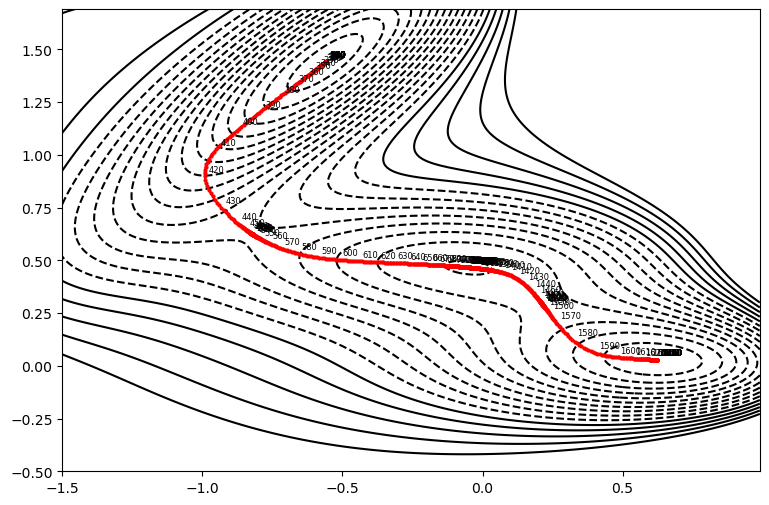

In [4]:
plot = ToyPlot()
plot.contour_range = np.arange(-200.0, 50.0, 10.0)
plot.add_pes(pes)
fig = plot.plot()

path1 = get_full_path(saddle_1)
path2 = get_full_path(saddle_2)

concat_path = np.concatenate([path1, path2], axis=0)

import matplotlib.pyplot as plt

plt.plot(concat_path[:, 0], concat_path[:, 1], '-o', color='red', markersize=2)
for i, (x,y) in enumerate(concat_path[::10]):
    idx = i*10
    plt.annotate(str(idx), (x,y), textcoords="offset points", xytext=(3,3), fontsize=6)


In [5]:
print(concat_path.shape)
for coord in concat_path:
    print(coord)
    break

(2004, 2)
[-0.55822366  1.44172582]


## Defining collective variables

TIS methods usually require that you define states and interfaces before starting the simulation. State and interfaces are both defined in terms of `Volume` objects. The most common type of `Volume` is one based on some set of collective variables, so the first thing we have to do is to define the collective variable.

For this system, we'll define the collective variables as circles centered on the middle of the state. OPS allows us to define one function for the circle, which is parameterized by different centers. Note that each collective variable is in fact a separate function.

In [6]:
def circle(snapshot, center):
    import math
    return math.sqrt((snapshot.xyz[0][0]-center[0])**2 + (snapshot.xyz[0][1]-center[1])**2)
    
opA = paths.CoordinateFunctionCV(name="opA", f=circle, center=[-0.5582228, 1.4417268])
# opC = paths.CoordinateFunctionCV(name="opC", f=circle, center=[-0.05001066, 0.466694])
opB = paths.CoordinateFunctionCV(name="opB", f=circle, center=[0.62349993, 0.02803773])

## Defining states and interfaces

Next we'll use those collective variables to define both states and interfaces. In this example, the innermost interface is the same as the state definition; this does not have to be the case, but when it is not, you should make sure that all frames in the state definition are also inside the innermost interface. The `VolumeInterfaceSet` gives a shortcut to create the full set of volume objects using the same collective variable.

In [7]:
stateA = paths.CVDefinedVolume(collectivevariable=opA, lambda_min=0.0, lambda_max=0.1)
stateB = paths.CVDefinedVolume(collectivevariable=opB, lambda_min=0.0, lambda_max=0.1)
# stateC = paths.CVDefinedVolume(collectivevariable=opC, lambda_min=0.0, lambda_max=0.2)

## Build the TPS transition network

Once we have the collective variables, states, and interfaces defined, we can create the entire transition network. In this one small piece of code, we create all the path ensembles needed for the simulation, organized into structures to assist with later analysis.

In [8]:
tps_network = paths.TPSNetwork(initial_states=stateA, final_states=stateB).named('tps_net')

## Equilibration: Setting up the move scheme

In the following, we will first do a (very) brief equilibration, and then 

In [9]:
modified_scheme = paths.OneWayShootingMoveScheme(
    network=tps_network,
    engine=engine
).named("2_way_from_1_way")

In [10]:
print(engine.integ.temperature)

3.0


In [11]:
# YOUR TURN: Set beta correctly (yes, this is as easy as you think).
beta = 1./engine.integ.temperature # fill in the ellipsis and uncomment this line

In [12]:
from openpathsampling import strategies
modifier = paths.RandomVelocities(beta=beta, engine=engine)
shooting_strategy = strategies.TwoWayShootingStrategy(modifier=modifier, engine=engine)

In [13]:
modified_scheme.append(shooting_strategy)

## Equilibration: get initial trajectory

In [14]:
# create a snapshot
init_traj = []

init_traj.append(
    toys.Snapshot(
        coordinates=np.array([[-0.5582228, 1.4417268]]),   # shape: (n_atoms, n_spatial)
        velocities=np.array([[0.0, 0.0]]),
        engine=engine
    )
) 

for coord in concat_path:
    snap = toys.Snapshot(
        coordinates=np.array([coord]),   # shape: (n_atoms, n_spatial)
        velocities=np.array([[0.0, 0.0]]),
        engine=engine
    )

    init_traj.append(snap) 

init_traj.append(
    toys.Snapshot(
        coordinates=np.array([[0.62349993, 0.02803773]]),   # shape: (n_atoms, n_spatial)
        velocities=np.array([[0.0, 0.0]]),
        engine=engine
    )
)

trajectory = paths.Trajectory(init_traj)

In [15]:
init_cond = modified_scheme.initial_conditions_from_trajectories(trajectory)

No missing ensembles.
No extra ensembles.


## Equilibration

In molecular dynamics, you need to equilibrate if you don't start with an equilibrium frame (e.g., if you start with solvent molecules on a grid, your system should equilibrate before you start taking statistics). Similarly, if you start with a set of paths which are far from the path ensemble equilibrium, you need to equilibrate. This could either be because your trajectories are not from the real dynamics (generated with metadynamics, high temperature, etc.) or because your trajectories are not representative of the path ensemble (e.g., if you put transition trajectories into all interfaces).

As with MD, running equilibration can be the same process as running the total simulation. However, in path sampling, it doesn't have to be: we can equilibrate without replica exchange moves or path reversal moves, for example. In the example below, we create a `MoveScheme` that only includes shooting movers.

In [16]:
equilibration = paths.PathSampling(
    storage=None,
    move_scheme=modified_scheme,
    sample_set=init_cond,
)

equilibration.run(100)

Working on Monte Carlo cycle number 100
Running for 16 minutes 8 seconds -  9.78 seconds per step
Estimated time remaining: 9 seconds
DONE! Completed 100 Monte Carlo cycles.


To continue with the equilibrated results (without having used a storage to save them), we extract the `sample_set` at the end of the calculation.

In [17]:
sset = equilibration.sample_set

In [18]:
print(modified_scheme.initial_conditions_report(sset))

No missing ensembles.
No extra ensembles.



## Running TPS

Now we have our initial conditions, so we'll make the storage and run the full calculation. 

Up to here, we haven't been storing any of our results. This time, we'll start a storage object, and we'll save the network we've created. Then we'll run a new `PathSampling` calculation object.

In [19]:
import os
if os.path.exists("muller_brown_simulation_results.nc"):
    os.remove("muller_brown_simulation_results.nc")

storage = paths.storage.Storage("muller_brown_simulation_results.nc", "w", template=snap)

In [20]:
tps_calc = paths.PathSampling(
    storage=storage,
    sample_set=sset,
    move_scheme=modified_scheme
)
tps_calc.save_frequency = 1

The next block sets up a live visualization. This is optional, and only recommended if you're using OPS interactively (which would only be for very small systems). Some of the same tools can be used to play back the behavior after the fact if you want to see the behavior for more complicated systems. You can create a background (here we use the PES contours), and the visualization will plot the trajectories.

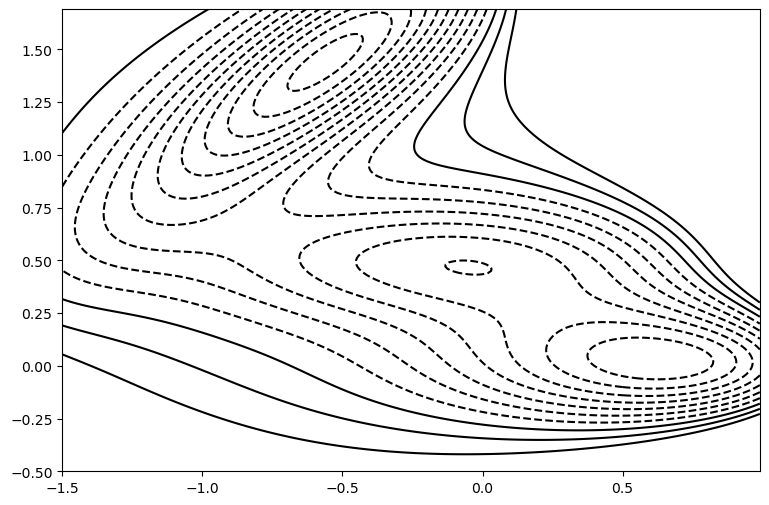

In [21]:
xval = paths.FunctionCV("xval", lambda snap : snap.xyz[0][0])
yval = paths.FunctionCV("yval", lambda snap : snap.xyz[0][1])
tps_calc.live_visualizer = paths.StepVisualizer2D(
    network=tps_network, 
    cv_x=xval, 
    cv_y=yval,
    xlim=[-2.0, 2.0],
    ylim=[-2.0, 2.0]
)
background = ToyPlot()
background.contour_range = np.arange(-200.0, 50.0, 15.0)
background.add_pes(engine.pes)
tps_calc.live_visualizer.background = background.plot()
tps_calc.status_update_frequency = 1 # increasing this number speeds things up, but isn't as pretty

The next question is, how many steps do we want to run? You can just choose an arbitrary number, but often we want to think in terms of how many shooting moves per ensemble. Assuming each ensemble has the same probability of doing a shooting move (as is the case in the `DefaultScheme`) we can select an arbitrary shooting mover as `scheme.movers['shooting'][0]`. Let's say we want to run enough moves that, on average, each shooting mover would do 10 steps. (In practice, this number would be more like 1000).

In [22]:
n_steps = modified_scheme.n_steps_for_trials(modified_scheme.movers['shooting'][0], 100)
print(n_steps)

100.0


Now everything is ready: let's run the simulation!

Note that the `n_steps` defined above is a `float`, so we need to turn it into an `int` first:

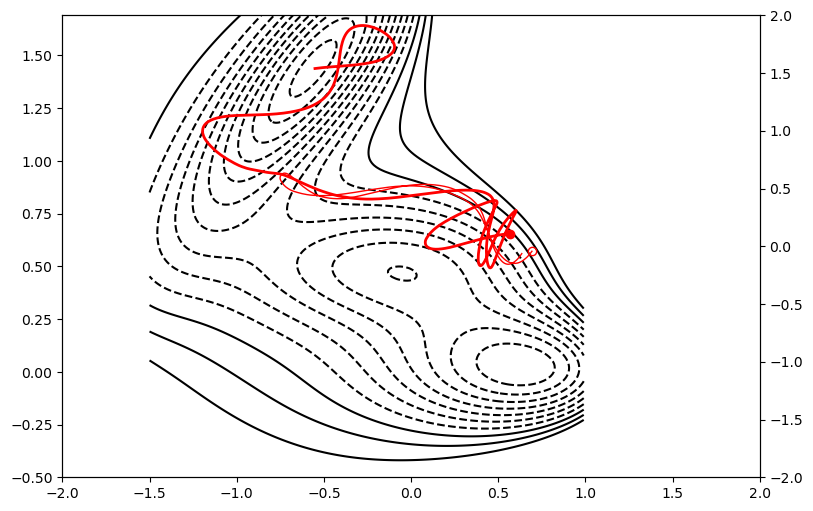

DONE! Completed 100 Monte Carlo cycles.


In [23]:
tps_calc.run(int(n_steps))

In [24]:
storage.close()